In [1]:
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np

In [2]:
df = pd.read_csv("diamonds.csv").dropna().drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


In [3]:
df.shape

(53940, 11)

In [4]:
df = df.drop(columns = ["Unnamed: 0"])
df.drop_duplicates(inplace=True)

In [5]:
df_ohe =  pd.get_dummies(df)
df_ohe.shape

(53794, 27)

In [6]:
df_ohe.columns


Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut_Fair',
       'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_D',
       'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J',
       'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1',
       'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2'],
      dtype='str')

In [7]:
X=df_ohe
from sklearn.model_selection import train_test_split
X_train,X_test = train_test_split(X,
                                  test_size=0.3,
                                  random_state=7)
X_train.shape,X_test.shape

((37655, 27), (16139, 27))

In [8]:
inertia_values = []
for k in range(2,11):
    kmm = KMeans(k,random_state=7)
    kmm.fit(X_train)
    inertia_values.append(kmm.inertia_)

c:\Users\ashis\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ashis\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ashis\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ashis\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", l

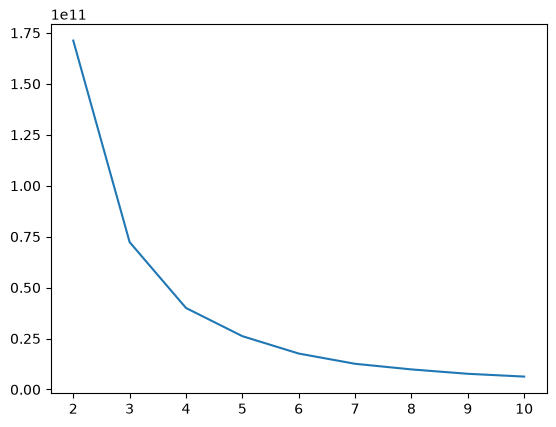

In [9]:
import matplotlib.pyplot as plt
plt.plot(list(range(2,11)), inertia_values)

In [ ]:
from sklearn.metrics import silhouette_score
y_pred = kmm.predict(X_test)
silhouette_score(X_test, y_pred)

In [ ]:
from sklearn.cluster import KMeans
kmm = KMeans(n_clusters=3,random_state=7,max_iter=100)
kmm.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",100
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",7
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 27)","[

In [ ]:
kmm.cluster_centers_

array([[1.11147319e+00, 6.18259394e+01, 5.78561212e+01, 5.73579562e+03,
        6.60750583e+00, 6.60462471e+00, 4.08278695e+00, 3.86946387e-02,
        1.13286713e-01, 3.03496503e-01, 2.98461538e-01, 2.46060606e-01,
        1.04428904e-01, 1.35664336e-01, 1.67272727e-01, 2.07552448e-01,
        1.92540793e-01, 1.16736597e-01, 7.58041958e-02, 1.82750583e-02,
        9.41724942e-03, 2.92587413e-01, 2.69930070e-01, 1.26993007e-01,
        2.12960373e-01, 2.12587413e-02, 4.85780886e-02],
       [1.71141042e+00, 6.16686519e+01, 5.78782955e+01, 1.33165809e+04,
        7.62631448e+00, 7.63196860e+00, 4.69939447e+00, 2.76601047e-02,
        7.47570396e-02, 3.37652629e-01, 3.42387241e-01, 2.17542985e-01,
        8.39770745e-02, 1.19362073e-01, 1.50510840e-01, 2.12060802e-01,
        1.91876402e-01, 1.67704959e-01, 7.45078495e-02, 5.98056317e-03,
        3.33914777e-02, 2.27012210e-01, 2.33241964e-01, 1.48517319e-01,
        2.12808373e-01, 5.08347869e-02, 8.82133068e-02],
       [4.91639394e-01

In [ ]:
y_pred = kmm.predict(X_test)
y_pred

array([2, 2, 1, ..., 0, 2, 2], shape=(16139,), dtype=int32)

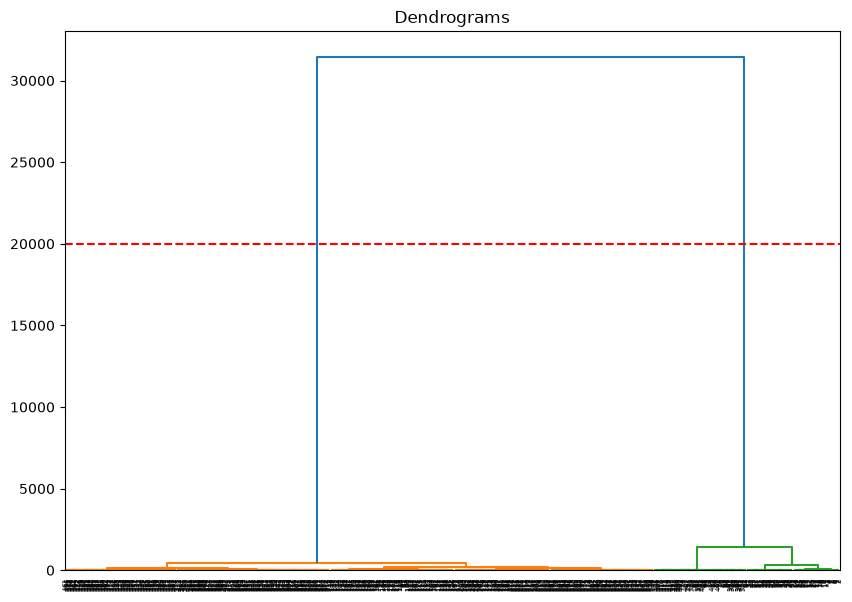

In [ ]:
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X.iloc[:500,:], method='ward'))
plt.axhline(y=20000, color='r', linestyle='--')

In [ ]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=3)
ac.fit(X_train.iloc[:500,:])

ac.fit_predict(X_train.iloc[:500,:])



array([1, 2, 2, 2, 1, 1, 2, 2, 2, 0, 2, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 1, 1, 0, 0, 0, 1, 2, 2, 1, 1, 1,
       1, 1, 1, 0, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 2, 0, 2, 1, 1,
       1, 0, 2, 1, 2, 2, 2, 2, 1, 2, 1, 0, 2, 2, 2, 0, 2, 1, 2, 2, 1, 2,
       2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 0, 1, 2, 2, 2, 1, 2, 2, 2,
       1, 1, 1, 0, 2, 0, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 1,
       0, 2, 2, 1, 0, 0, 1, 0, 1, 2, 2, 2, 0, 2, 2, 2, 1, 0, 1, 2, 2, 2,
       2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2, 2, 1, 1, 2, 2, 0, 1, 2, 2, 0,
       1, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 0,
       2, 0, 2, 0, 2, 2, 1, 2, 0, 2, 2, 0, 2, 0, 2, 1, 0, 1, 2, 1, 1, 1,
       2, 2, 2, 1, 1, 1, 0, 1, 0, 1, 2, 2, 1, 1, 0, 0, 2, 2, 1, 2, 1, 2,
       2, 1, 2, 2, 2, 2, 1, 1, 0, 1, 2, 2, 2, 2, 1,

In [ ]:
from sklearn.cluster import AgglomerativeClustering
